In [1]:
import os
import pandas as pd
import geopandas as gpd
import rasterio
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
base_dir = '../../../../datos-notebooks/3.global-data-cba/'
ground_data_name = 'anemometers_160226.csv'

ground_data_path = os.path.join(base_dir, 'MRT-prediction/ground_data', ground_data_name)

In [3]:
df = pd.read_csv(ground_data_path, sep=",")

In [4]:
print(df.columns)

Index(['A1', 'A2'], dtype='object')


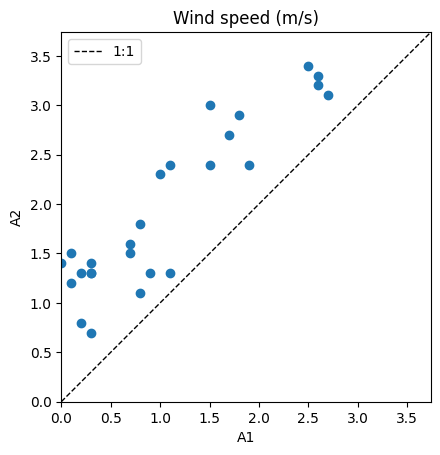

In [18]:
# Variables
x = df["A1"].values
y = df["A2"].values

plt.figure()
plt.scatter(x, y)
plt.title("Wind speed (m/s)")
plt.xlabel("A1")
plt.ylabel("A2")

lim_max = max(x.max(), y.max()) * 1.1
plt.xlim(0, lim_max)
plt.ylim(0, lim_max)
plt.gca().set_aspect('equal')
plt.plot([0, lim_max], [0, lim_max], 'k--', linewidth=1, label='1:1')
plt.legend()
plt.show()

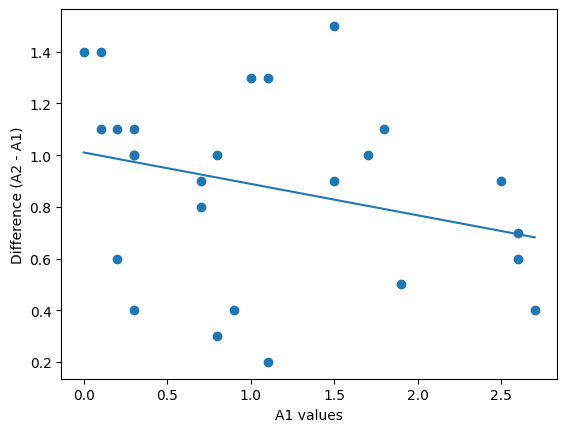

In [6]:
# Variables
df["diff"] = df["A2"].values - df["A1"].values


x_line = np.linspace(df["A1"].min(),
                     df["A1"].max(), 100)

coef = np.polyfit(df["A1"], df["diff"], 1)

y_line = coef[0] * x_line + coef[1]

# Plot
plt.figure()
plt.scatter(df["A1"], df["diff"])
plt.plot(x_line, y_line)
plt.xlabel("A1 values")
plt.ylabel("Difference (A2 - A1)")
plt.show()

In [7]:
# Reference: Anemometer 1
X = df[["A1"]]
y = df["A2"]

# Fit relation A2 = a*A1 + b
model = LinearRegression()
model.fit(X, y)

a = model.coef_[0]
b = model.intercept_

# Print applied correction (express A2 in A1 scale)
print("Applied correction:")
print(f"A2_corrected = (A2 - {b:.4f}) / {a:.4f}")

# Calibrate A2 to A1 scale
df["A2_corr"] = ((df["A2"] - b) / a).round(2).clip(lower=0) 

Applied correction:
A2_corrected = (A2 - 1.0102) / 0.8785


In [8]:
df

,A1,A2,diff,A2_corr
0,0.1,1.5,1.4,0.56
1,0.3,1.3,1.0,0.33
2,0.3,1.4,1.1,0.44
3,0.2,1.3,1.1,0.33
4,0.1,1.2,1.1,0.22
5,0.0,1.4,1.4,0.44
6,0.2,0.8,0.6,0.00
7,0.3,0.7,0.4,0.00
8,0.7,1.6,0.9,0.67
9,0.8,1.8,1.0,0.90
